In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 12}

plt.rc('font', **font)
plot_fs = 12

plt.rc('font', family='serif', serif='Times')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)
plt.rc('axes', labelsize=10)
mpl.rcParams['lines.dashed_pattern'] = [2, 2]
mpl.rcParams['lines.linewidth'] = 1.0

import pathlib
cur_dir = pathlib.Path().cwd()
parent_dir = cur_dir.parent

import sys
print(sys.version)
sys.path.append('../')

from models.powertrain.bounded_powertrain import Bounded_powertrain
from models.kinematic.ideal_diff_drive import Ideal_diff_drive
from models.learning.blr_slip import SlipBayesianLinearRegression, FullBodySlipBayesianLinearRegression
from models.learning.blr_slip_acceleration import SlipAccelerationBayesianLinearRegression, FullBodySlipAccelerationBayesianLinearRegression
from models.kinematic.ICR_based import *
from models.kinematic.Perturbed_unicycle import *
from models.kinematic.enhanced_kinematic import *
from NicolasSamson.script.compute_command_fig import * 
from util.transform_algebra import *
from util.util_func import *
from data_utils.dataset_parser import *

3.8.19 (default, Apr  6 2024, 17:58:10) 
[GCC 11.4.0]


# Visualiser la vitesse. 

In [17]:


#dataset_path = '../data/ral2023_dataset/warthog_wheels/ice/acceleration_dataset.pkl'
dataset_path = '../data/ral2023_dataset/warthog_wheels/ice/warthog_wheels_ice_rink_data-raw.pkl'

full_dataset = pd.read_pickle(dataset_path)

column_to_float = ['meas_left_vel', 'meas_right_vel', 'cmd_vel_x', 'cmd_vel_omega',
       'icp_pos_x', 'icp_pos_y', 'icp_pos_z', 'icp_quat_x', 'icp_quat_y',
       'icp_quat_z', 'icp_quat_w', 'imu_x', 'imu_y', 'imu_z',
       'imu_acceleration_x', 'imu_acceleration_y', 'imu_acceleration_z']

### Ajust the type
for col in column_to_float:

    full_dataset[col] = full_dataset[col].astype(float)

In [18]:
print(full_dataset.columns)

Index(['ros_time', 'joy_switch', 'icp_index', 'calib_state', 'calib_step',
       'meas_left_vel', 'meas_right_vel', 'cmd_vel_x', 'cmd_vel_omega',
       'icp_pos_x', 'icp_pos_y', 'icp_pos_z', 'icp_quat_x', 'icp_quat_y',
       'icp_quat_z', 'icp_quat_w', 'imu_x', 'imu_y', 'imu_z',
       'imu_acceleration_x', 'imu_acceleration_y', 'imu_acceleration_z'],
      dtype='object')



#### Conclusion
Les dataframes "_data-raw.pkl" ne contient pas la vitesse. Par contre, les datasets "torch_dataset_all.pkl" contient les vitesses raw calcu/e par ICP soit la derivee de la transformation entre deux positions.

En modifiant le noeud DATAPARSER, it should be possible to add a column estimating the initial speed as the first speed calculated. 




### Validation de la vitesse 

In [19]:
###
dataset_path = '../data/ral2023_dataset/warthog_wheels/ice/torch_dataset_all.pkl'
dataset_torch_all = pd.read_pickle(dataset_path)

print(dataset_torch_all.columns)
print("once removing the columns _XX")

Index(['init_icp_x', 'init_icp_y', 'init_icp_z', 'init_icp_roll',
       'init_icp_pitch', 'init_icp_yaw', 'calib_step', 'cmd_left_0',
       'cmd_right_0', 'cmd_left_1',
       ...
       'imu_acceleration_z_38', 'imu_acceleration_x_39',
       'imu_acceleration_y_39', 'imu_acceleration_z_39', 'gt_icp_x',
       'gt_icp_y', 'gt_icp_z', 'gt_icp_roll', 'gt_icp_pitch', 'gt_icp_yaw'],
      dtype='object', length=578)
once removing the columns _XX


The speed of each calib step was only computed with the means. Therefore, I modified the dataparser to add 40 columns that each represent the icp_speed at the 0.05 rate. Created a new version of the dataset _v2 with the python script 

'data/ral2023_dataset/warthog_wheels/ice/torch_dataset_all_v2.pkl'


In [20]:
# Load dataframe
dataset_v2_path = '../data/ral2023_dataset/warthog_wheels/ice/torch_dataset_all_v2.pkl'
dataset_v2 = pd.read_pickle(dataset_v2_path)

['init_icp_x' 'init_icp_y' 'init_icp_z' 'init_icp_roll' 'init_icp_pitch'
 'init_icp_yaw' 'calib_step' 'cmd_left' 'cmd_right' 'left_wheel_vel'
 'right_wheel_vel' 'icp_x' 'icp_y' 'icp_z' 'icp_roll' 'icp_pitch'
 'icp_yaw' 'imu_yaw' 'icp_vx' 'icp_vy' 'icp_omega' 'steady_state_mask'
 'transitory_state_mask' 'imu_acceleration_x' 'imu_acceleration_y'
 'imu_acceleration_z' 'gt_icp_x' 'gt_icp_y' 'gt_icp_z' 'gt_icp_roll'
 'gt_icp_pitch' 'gt_icp_yaw' 'icp_vel_x' 'icp_vel_y' 'icp_vel_yaw']
The column type: icp_vel_x
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 0.012966344318198394
Minimum -0.011413082475178684


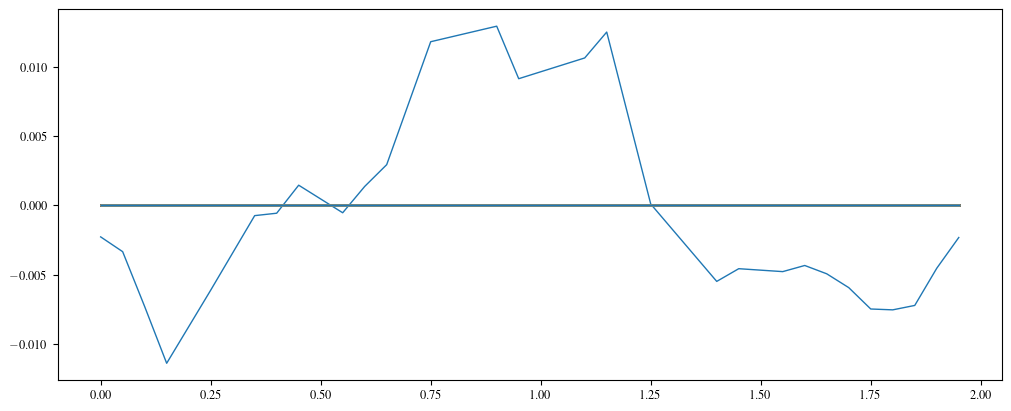

In [27]:

print_column_unique_column(dataset_v2)
icp_vel_x = column_type_extractor(dataset_v2, 'icp_vel_x',verbose=True)

rate = 0.05 
n = icp_vel_x.shape[1]
time_axis = create_time_axe(rate,n)

fig, axs =  plt.subplots(1, 1, layout='constrained', figsize=(10, 4))


for i in range(591):
    
    axs.plot(time_axis,icp_vel_x[i,:],label=f'{i}')

df = pd.DataFrame(icp_vel_x)

df.to_csv('../NicolasSamson/resultat_inter/vel_icp_x.csv')


### Finir le graphique ===== subplot ou en haut left, wright,

Faire deux graphique, soit 1 ou on ramene les commandes dans le domaines des roues pour voir si les roues atteigne le regime permanent 


Faire un deuxi'eme graphique ou les mesures d'encodeur sont ramen/es dans le body frame avec Ideal-diff-drive pour voir si selon les roues on atteint le regime permanent 



Refaire la meme chose avec le dataset suivant pour comparer le regime permanent. 

Mais ne r/pond pas a la question actuelle qui est pourquoi la metric ne fonctionne pas sur la glace. Meilleur reponse est de map la commande dans la figure. 

Au final, j'ai seulement besoin du min max encodeur et le transferer dans le repere body.  

Zoomer sur le signal pour voir le max et le min. 

Prendre le script run_experiment pour record un bag avec mapping. 

<Axes: xlabel='ros_time'>

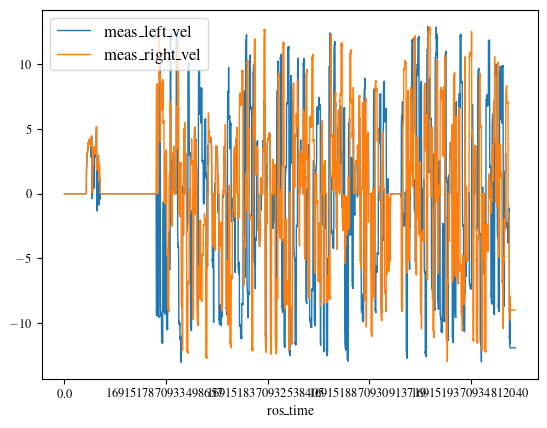

In [9]:

full_dataset.plot("ros_time",["meas_left_vel","meas_right_vel"])
